<a href="https://colab.research.google.com/github/Hala-sala7/Prediction_of_Product_Sales_ML/blob/main/Prediction_of_Product_Sales_Ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/data')

Mounted at /content/data


In [ ]:
fname="/content/data/MyDrive/AXSOSACADEMY/02-IntroML/Week05/Data/sales_predictions_2023.csv"

In [ ]:
import pandas as pd
df=pd.read_csv(fname)

In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
duplicated_raws=df.duplicated()
duplicated_raws

,0
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
object_columns = df.select_dtypes('object').columns
object_columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
zeros_count = (df['Item_Visibility'] == 0).sum()
zeros_count

np.int64(526)

Upon investigation, 526 items were found to have a visibility value of exactly 0.0. This is logically inconsistent since any product currently on sale must occupy some physical shelf space.

<Axes: xlabel='Item_Visibility', ylabel='Count'>

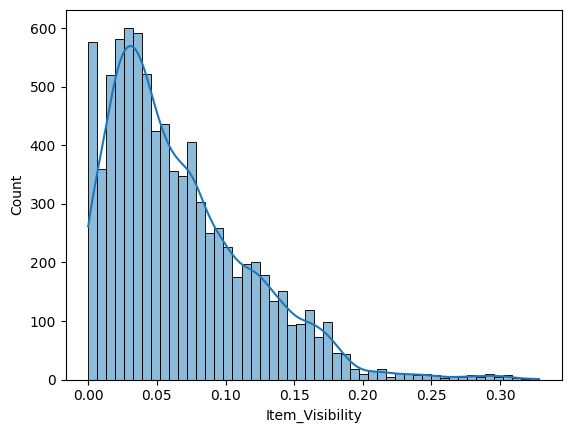

In [ ]:
import seaborn as sns
sns.histplot(df['Item_Visibility'], bins=50, kde=True)

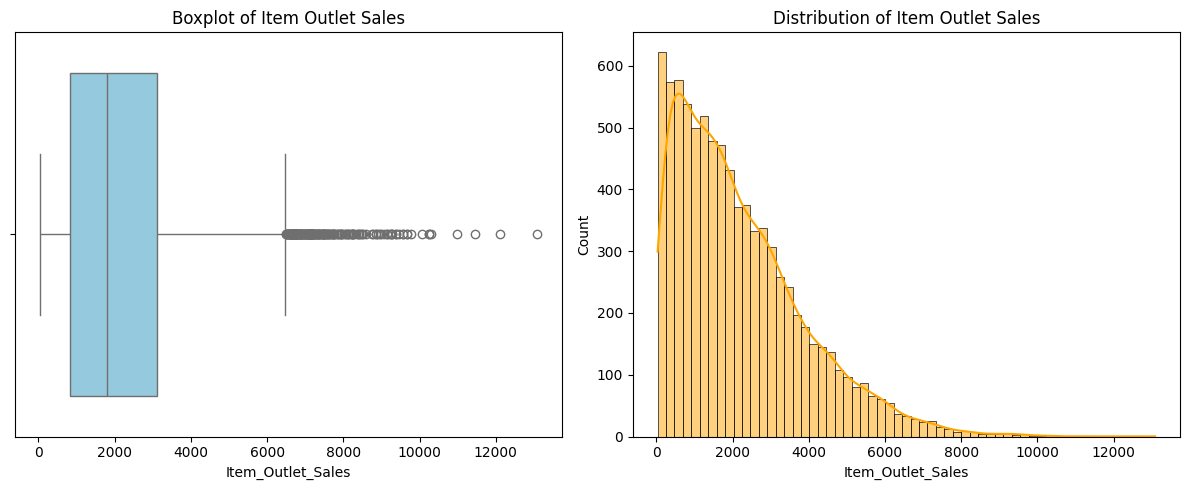

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Item_Outlet_Sales'], color='skyblue')
plt.title('Boxplot of Item Outlet Sales')

plt.subplot(1, 2, 2)
sns.histplot(df['Item_Outlet_Sales'], kde=True, color='orange')
plt.title('Distribution of Item Outlet Sales')

plt.tight_layout()
plt.show()

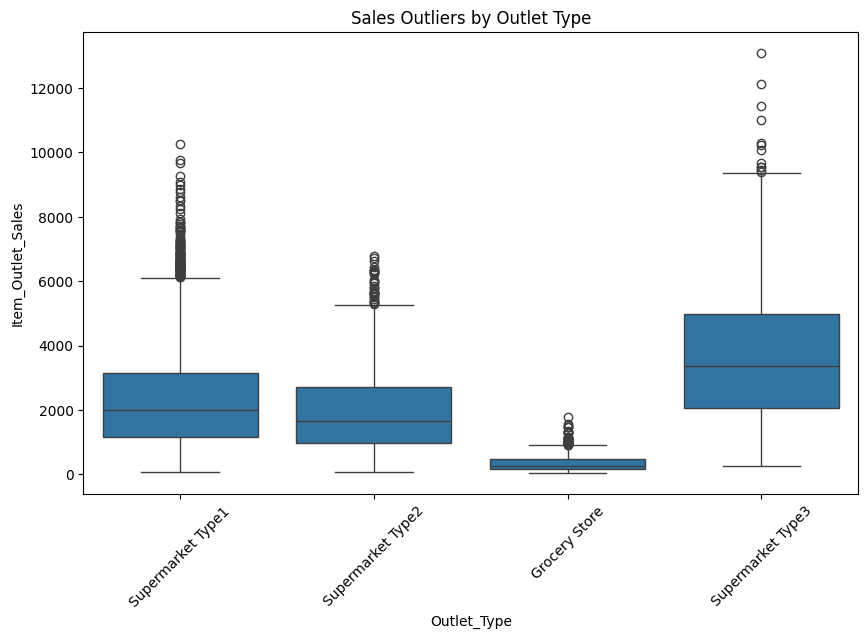

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.xticks(rotation=45)
plt.title('Sales Outliers by Outlet Type')
plt.show()

Unique Outlet Types: ['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


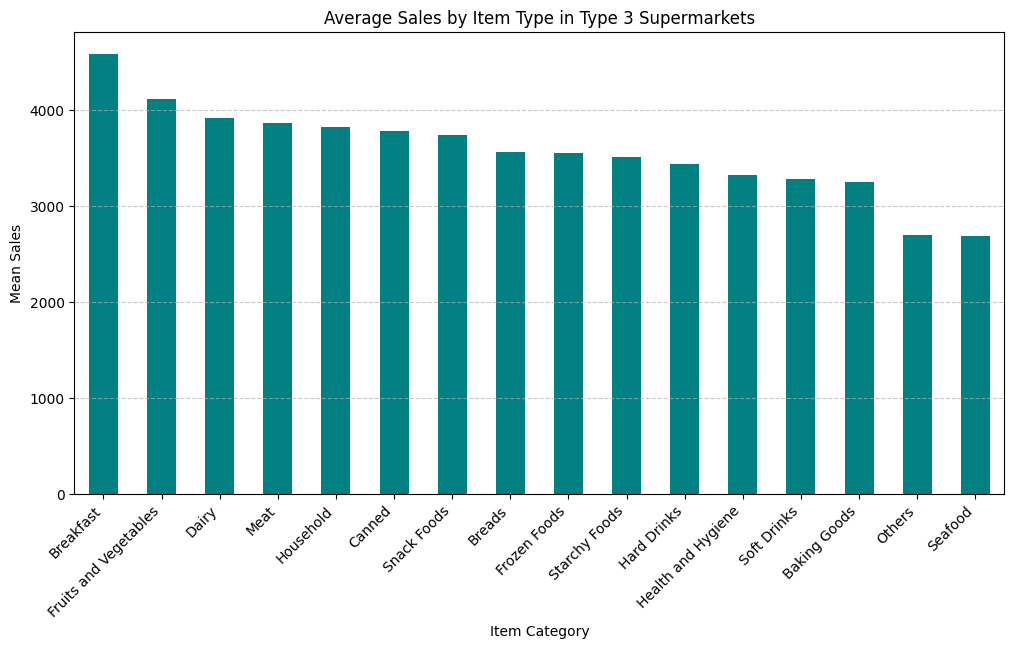

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check the exact names in the column to avoid typos
print("Unique Outlet Types:", df['Outlet_Type'].unique())

# 2. Filter for Type 3 (using a flexible string match to avoid space/typo issues)
# This looks for any string containing 'Type3' or 'Type 3'
type3_df = df[df['Outlet_Type'].str.contains('Type 3|Type3', case=False, na=False)]

# 3. Plot if the data exists
if not type3_df.empty:
    plt.figure(figsize=(12, 6))

    # Calculate mean sales per item type
    mean_sales = type3_df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

    # Plotting
    mean_sales.plot(kind='bar', color='teal')
    plt.title('Average Sales by Item Type in Type 3 Supermarkets')
    plt.ylabel('Mean Sales')
    plt.xlabel('Item Category')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("DataFrame is still empty. Please check the 'Outlet_Type' column values.")

Initially, the maximum sales value of 13,000 raised concerns regarding data integrity or potential entry errors. However, observing a continuous gradient of outliers—rather than a single isolated point—suggested a systematic pattern rather than a random error.

To investigate further, I performed a Segmented Analysis by linking sales to Outlet Types. The results revealed that these high values were exclusive to Supermarket Type 3 (the largest store format). Further breakdown showed that essential categories, specifically Breakfast and Fresh Produce, were the primary drivers. Consequently, I decided to retain these outliers, as they represent genuine business performance that is critical for the model to capture.

In [ ]:
for col in object_columns:
  print(f'value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [ ]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({"Low Fat": "low fat",
    "LF": "low fat",
     "reg":"Regular"})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
low fat,5517
Regular,3006


In [ ]:
y=df['Item_Outlet_Sales']

In [ ]:
X=df.drop(columns=['Item_Outlet_Sales'])
X


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,9.300,low fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,FDN15,17.500,low fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,NCD19,8.930,low fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,low fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1
8520,NCJ29,10.600,low fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42)

In [ ]:
id_map = X_train.groupby('Item_Identifier')['Item_Weight'].mean()
type_map = X_train.groupby('Item_Type')['Item_Weight'].mean()

X_train['Item_Weight'] = X_train['Item_Weight'].fillna(X_train['Item_Identifier'].map(id_map))
X_train['Item_Weight'] = X_train['Item_Weight'].fillna(X_train['Item_Type'].map(type_map))

X_test['Item_Weight'] = X_test['Item_Weight'].fillna(X_test['Item_Identifier'].map(id_map))
X_test['Item_Weight'] = X_test['Item_Weight'].fillna(X_test['Item_Type'].map(type_map))

In [ ]:
import numpy as np

X_train['Item_Visibility'] = X_train['Item_Visibility'].replace(0, np.nan)
X_test['Item_Visibility'] = X_test['Item_Visibility'].replace(0, np.nan)

min_visibility_map = X_train.groupby('Item_Type')['Item_Visibility'].min()

X_train['Item_Visibility'] = X_train['Item_Visibility'].fillna(X_train['Item_Type'].map(min_visibility_map))
X_test['Item_Visibility'] = X_test['Item_Visibility'].fillna(X_test['Item_Type'].map(min_visibility_map))

X_train['Item_Visibility'].fillna(X_train['Item_Visibility'].min(), inplace=True)

/tmp/ipykernel_26111/3835829979.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Item_Visibility'].fillna(X_train['Item_Visibility'].min(), inplace=True)


Handling Logical Errors in Item Visibility:

The dataset contained 526 entries where Item_Visibility was recorded as 0.0. This is logically impossible for products that are actively being sold in a store.

Rationale for Imputation:
Instead of using a simple mean or median, which might artificially inflate the visibility of poorly placed items, I opted for a "Minimum Presence" strategy:

Data Correction: All 0.0 values were treated as missing data (NaN).

Contextual Imputation: Missing values were filled using the Minimum Visibility recorded for that specific Item_Type.

Objective: This approach preserves the realistic assumption that these products are likely placed in low-visibility areas of the store, maintaining the lower-bound variance of the feature without introducing the bias of a zero value.

In [ ]:
X_train['Item_Visibility'].min()

0.003574698

In [ ]:
from sklearn.impute import SimpleImputer
num_cols=X_train.select_dtypes("number").columns
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')

In [ ]:
X_train['Item_Weight'].isna().sum()

np.int64(0)

In [ ]:
X_test['Item_Weight'].isna().sum()

np.int64(0)

In [ ]:
df['Outlet_Establishment_Year']

,Outlet_Establishment_Year
0,1999
1,2009
2,1999
3,1998
4,1987
...,...
8518,1987
8519,2002
8520,2004
8521,2009


In [ ]:
df['Item_Visibility']

,Item_Visibility
0,0.016047
1,0.019278
2,0.016760
3,0.000000
4,0.000000
...,...
8518,0.056783
8519,0.046982
8520,0.035186
8521,0.145221


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

num_tuple = ('numeric', num_pipe, num_cols)

In [ ]:
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


In [ ]:
obj_cols=X_train.select_dtypes("object").columns
obj_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
tier_order = ['Tier 1', 'Tier 2', 'Tier 3']


ord_columns = ['Outlet_Location_Type']

ord_encoder = OrdinalEncoder(categories=[tier_order])

ord_pipe = make_pipeline(ord_encoder)

ord_tuple = ('ordinal', ord_pipe, ord_columns)

In [ ]:
id_mode = X_train.groupby('Outlet_Identifier')['Outlet_Size'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

type_mode = X_train.groupby('Outlet_Type')['Outlet_Size'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else "Medium"
)


X_train['Outlet_Size'] = X_train['Outlet_Size'].fillna(X_train['Outlet_Identifier'].map(id_mode))
X_test['Outlet_Size'] = X_test['Outlet_Size'].fillna(X_test['Outlet_Identifier'].map(id_mode))

X_train['Outlet_Size'] = X_train['Outlet_Size'].fillna(X_train['Outlet_Type'].map(type_mode))
X_test['Outlet_Size'] = X_test['Outlet_Size'].fillna(X_test['Outlet_Type'].map(type_mode))

In [ ]:
X_train['Outlet_Size'].isna().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_columns).columns

print("OneHotEncoder Columns:", ohe_cols)

impute_most = SimpleImputer(strategy='most_frequent')
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_pipe = make_pipeline(impute_most, ohe_encoder)

ohe_pipe

OneHotEncoder Columns: Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Type'],
      dtype='object')


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

In [ ]:
from sklearn.compose import ColumnTransformer
col_transformer = ColumnTransformer([num_tuple,ord_tuple,
ohe_tuple],verbose_feature_names_out=False)

In [ ]:
col_transformer.fit(X_train)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Tier '
                                                                              '1',
                                                                              'Tier '
                                                                              '2',
                                                                              'Tier '
                                                                              '3']]))]),
                                 ['Outlet_Location_Type']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Type'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [ ]:
X_train_processed =col_transformer.transform(X_train)
X_train_processed = pd.DataFrame(X_train_processed)

X_test_processed =col_transformer.transform(X_test)
X_test_processed = pd.DataFrame(X_test_processed)

X_train_processed.head()

,0,1,2,3,4,5,6,7,8,9,...,1580,1581,1582,1583,1584,1585,1586,1587,1588,1589
0,0.736235,-0.727846,1.828109,1.327849,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.498372,-1.194604,0.603369,1.327849,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.128722,1.823203,0.244541,0.136187,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-1.074768,-1.022888,-0.952591,0.732018,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.384953,-0.983051,-0.336460,0.493686,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg

LinearRegression()

In [ ]:
lin_pipe = make_pipeline(col_transformer, lin_reg)
lin_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categorie...
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Type'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import pandas as pd

def regression_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    # Get metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r_squared = r2_score(y_true, y_pred)

    if verbose:
        header = "-" * 60
        print(header, f"Regression Metrics: {label}", header, sep='\n')
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")

    if output_dict:
        metrics = {'Label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R^2': r_squared}
        return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose=True, output_frame=False):
    # Training predictions
    y_train_pred = reg.predict(X_train)
    results_train = regression_metrics(y_train, y_train_pred, verbose=verbose,
                                     output_dict=output_frame, label='Training Data')

    print()

    # Testing predictions
    y_test_pred = reg.predict(X_test)
    results_test = regression_metrics(y_test, y_test_pred, verbose=verbose,
                                    output_dict=output_frame, label='Test Data')

    if output_frame:
        results_df = pd.DataFrame([results_train, results_test])
        results_df = results_df.set_index('Label')
        results_df.index.name = None
        return results_df.round(3)

In [ ]:
evaluate_regression(lin_reg, X_train_processed, y_train, X_test_processed, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 735.733
- MSE = 971,599.484
- RMSE = 985.697
- R^2 = 0.672

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 967.426
- MSE = 1,701,424.659
- RMSE = 1,304.387
- R^2 = 0.383


## Model Performance Analysis (Linear Regression)
The current Linear Regression model is clearly suffering from Overfitting. This can be analyzed through the following points:The Performance Gap: There is a significant discrepancy between the model's accuracy on the training set ($R^2 = 0.672$) and its performance on the test set ($R^2 = 0.383$).Generalization Failure: The large drop in $R^2$ (approximately 29%) indicates that the model has "memorized" the specific noise and patterns in the training data rather than learning the underlying general relationships.

Conclusion: The model performs well on data it has already seen but fails to generalize to new, unseen data, making it unreliable for predicting actual sales.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline

rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(col_transformer, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 298.333
- MSE = 185,211.802
- RMSE = 430.362
- R^2 = 0.937

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 771.714
- MSE = 1,236,111.202
- RMSE = 1,111.805
- R^2 = 0.552


## Model Performance Analysis (Random Forest)
Significant Improvement: Compared to the Linear Regression model, which had an $R^2$ of 38.3% on the test set, the Random Forest model increased the accuracy to 55.2%.

Capturing Complexity: This improvement indicates that the new model is much better at understanding the non-linear and complex relationships within the data.

Persistent Overfitting: Despite the improvement, there is still a substantial gap between the training performance (93.7%) and the test performance (55.2%).

Generalization Challenges: While the model is "highly proficient" on the training data, it still struggles to generalize with the same level of efficiency to new, unseen data.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'randomforestregressor__max_depth': [5, 10, 15],
    'randomforestregressor__n_estimators': [100, 150, 200],
    'randomforestregressor__min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

evaluate_regression(best_rf_model, X_train, y_train, X_test, y_test)

Best Parameters: {'randomforestregressor__max_depth': 5, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 100}
------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.702
- MSE = 1,154,421.074
- RMSE = 1,074.440
- R^2 = 0.610

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 727.694
- MSE = 1,091,321.682
- RMSE = 1,044.663
- R^2 = 0.604


## Analysis of Tuned Model Performance:
Significant Reduction in Overfitting: The default Random Forest model showed a massive gap between training (0.937) and testing (0.552) $R^2$ scores.
After hyperparameter tuning, this gap was virtually eliminated, with scores of 0.610 and 0.604 respectively.

Improved Generalization: By constraining the model (using max_depth: 5 and min_samples_leaf: 5), we prevented it from memorizing noise.
This resulted in a 5.2% absolute improvement in the test $R^2$ score.

Conclusion: The tuned model is far more robust and reliable for real-world sales predictions compared to the default model.